### Y6 GOLD vs METACAL

In [1]:
from astropy.table import Table
import pandas as pd
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
from scipy.stats import linregress

Como el archivo de METACAL es muy grande, vamos a hacer el crossmatch con Y6 GOLD en TopCat.

In [2]:
#Escribimos la ruta completa al archivo que contiene el crossmatch
crossmatch_y6_gold_metacal_file = '/mnt/c/Users/Leire/Downloads/xmatch_y6_gold_metacal.csv'
crossmatch_y6_gold_metacal = pd.read_csv(crossmatch_y6_gold_metacal_file)

In [3]:
print(crossmatch_y6_gold_metacal.columns.tolist())

['sheared_1m_t', 'sheared_1m_t_err', 'sheared_1m_e_1', 'sheared_1m_e_2', 'sheared_1p_t', 'sheared_1p_t_err', 'sheared_1p_e_1', 'sheared_1p_e_2', 'sheared_2m_t', 'sheared_2m_t_err', 'sheared_2m_e_1', 'sheared_2m_e_2', 'sheared_2p_t', 'sheared_2p_t_err', 'sheared_2p_e_1', 'sheared_2p_e_2', 'unsheared_t', 'unsheared_t_err', 'unsheared_mcal_psf_t', 'unsheared_mcal_psf_e1', 'unsheared_mcal_psf_e2', 'unsheared_psf_t', 'unsheared_psf_e1', 'unsheared_psf_e2', 'unsheared_ra', 'unsheared_e_1', 'unsheared_e_2', 'unsheared_dec', 'Index_1', 'J2000_NAME', 'OCARS_NAME', 'DEC', 'RA', 'DEC_deg', 'RA_deg', 'INDEX_NEW_TABLE', 'RA_ERR_sec', 'DEC_ERR_arcsec', 'RA_ERR_deg', 'DEC_ERR_deg', 'SKY_PA_ERR_deg', 'RA_DEC_CORRELATION', 'SEMIMAJOR_AXIS_OF_ERROR_ELLIPSE_mas', 'CATALOG_CODE', 'EPOCH_YEAR', 'GAL_LON_deg', 'GAL_LAT_deg', 'Z_FROM_NED_OR_LITERATURE', 'Z', 'Z_FLAG', 'Z_SIMBAD', 'Z_SIMBAD_FLAG', 'Z_SDSS', 'OPTICAL_OR_NIR_MAGNITUDE', 'BAND', 'OBJECT_PRIMARY_TYPE', 'OTHER_ID_AND_NOTES', 'J2000', 'frequencies'

In [4]:
print(crossmatch_y6_gold_metacal.shape)

(724, 124)


In [5]:
#Con esto quitamos los objetos que tengan valores de -9990.0 en cualquiera de estas columnas
columnas_malas_y6_metacal = ['BDF_G_1', 'BDF_G_2', 'PSF_G_1', 'PSF_G_2',
                             'unsheared_mcal_psf_e1', 'unsheared_psf_e1', 'sheared_1m_e_1', 'sheared_2m_e_1', 'sheared_1p_e_1', 'sheared_2p_e_1',
                             'unsheared_mcal_psf_e2', 'unsheared_psf_e2','sheared_1m_e_2', 'sheared_2m_e_2', 'sheared_1p_e_2', 'sheared_2p_e_2']

mask_y6_metacal = ~(crossmatch_y6_gold_metacal[columnas_malas_y6_metacal] < -9990.0).any(axis=1)

crossmatch_y6_gold_metacal_clean = crossmatch_y6_gold_metacal[mask_y6_metacal].copy()

print('Objetos totales antes:', len(crossmatch_y6_gold_metacal))
print('Objetos eliminados:', (~mask_y6_metacal).sum())
print('Objetos restantes:', len(crossmatch_y6_gold_metacal_clean))

Objetos totales antes: 724
Objetos eliminados: 13
Objetos restantes: 711


In [6]:
#Filtramos por los que sean galaxias
crossmatch_y6_gold_metacal_good = crossmatch_y6_gold_metacal_clean[(crossmatch_y6_gold_metacal_clean['DES_full_catalogue_Astrogeo_EXTENDED_CLASS_COADD_matches'].isin([2, 3]))]

In [7]:
print('Objetos totales antes:', len(crossmatch_y6_gold_metacal))
print('Objetos eliminados:', (~mask_y6_metacal).sum())
print('Objetos restantes:', len(crossmatch_y6_gold_metacal_clean))
print('Galaxias:', len(crossmatch_y6_gold_metacal_good))

Objetos totales antes: 724
Objetos eliminados: 13
Objetos restantes: 711
Galaxias: 247


#### Elipticidades Y6 GOLD BDF vs METACAL

Regresión lineal: y = 0.9947*x + 0.0013
Coeficiente de correlación (r): 0.8183
Error estándar: 0.0446
p-valor: 7.4460e-61


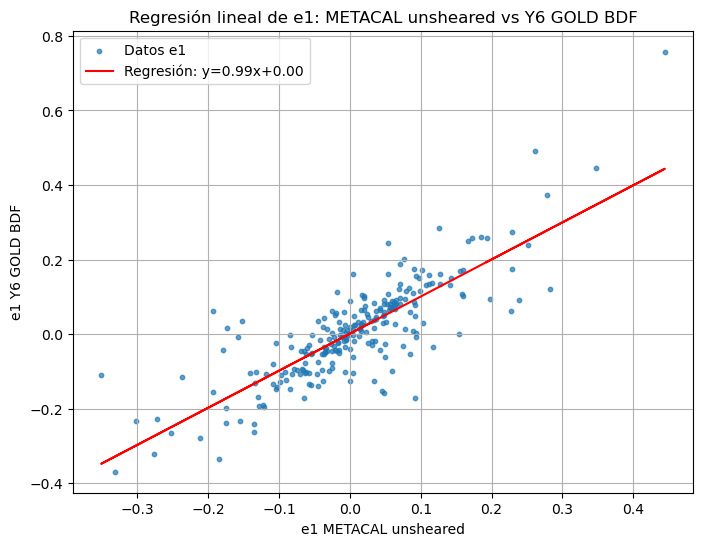

In [8]:
#Extraemos las columnas e1 de ambos surveys de los datos crossmatched
x = crossmatch_y6_gold_metacal_good['unsheared_e_1']
y = crossmatch_y6_gold_metacal_good['BDF_G_1']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos e1')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('e1 METACAL unsheared')
plt.ylabel('e1 Y6 GOLD BDF')
plt.title('Regresión lineal de e1: METACAL unsheared vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 0.8624*x + -0.0049
Coeficiente de correlación (r): 0.7668
Error estándar: 0.0461
p-valor: 4.4820e-49


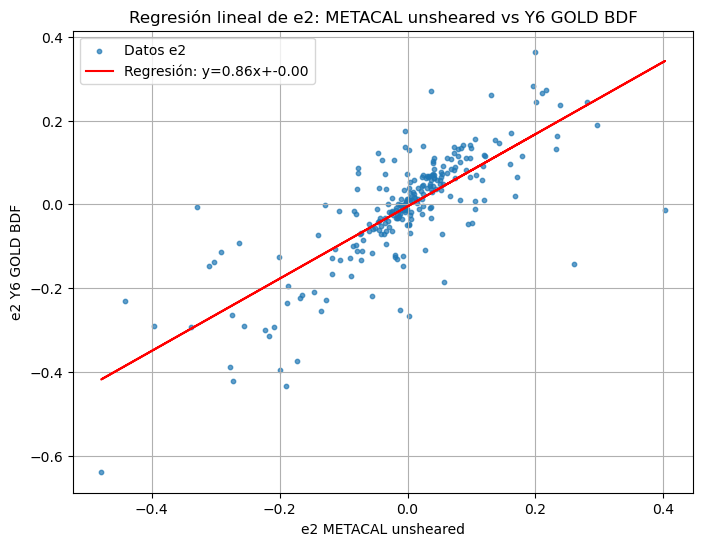

In [9]:
#Extraemos las columnas e1 de ambos surveys de los datos crossmatched
x = crossmatch_y6_gold_metacal_good['unsheared_e_2']
y = crossmatch_y6_gold_metacal_good['BDF_G_2']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos e2')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('e2 METACAL unsheared')
plt.ylabel('e2 Y6 GOLD BDF')
plt.title('Regresión lineal de e2: METACAL unsheared vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 0.9583*x + 0.0077
Coeficiente de correlación (r): 0.7959
Error estándar: 0.0466
p-valor: 2.6385e-55


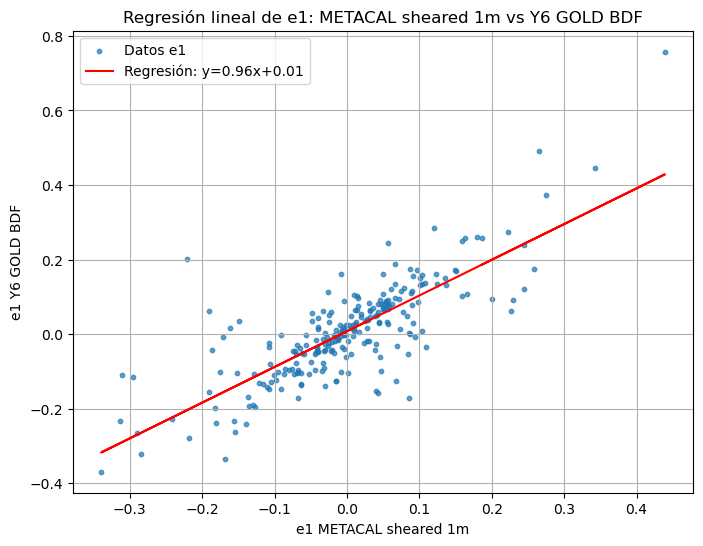

In [10]:
#Extraemos las columnas e1 de ambos surveys de los datos crossmatched
x = crossmatch_y6_gold_metacal_good['sheared_1m_e_1']
y = crossmatch_y6_gold_metacal_good['BDF_G_1']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos e1')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('e1 METACAL sheared 1m')
plt.ylabel('e1 Y6 GOLD BDF')
plt.title('Regresión lineal de e1: METACAL sheared 1m vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 0.7556*x + -0.0036
Coeficiente de correlación (r): 0.7155
Error estándar: 0.0471
p-valor: 4.8847e-40


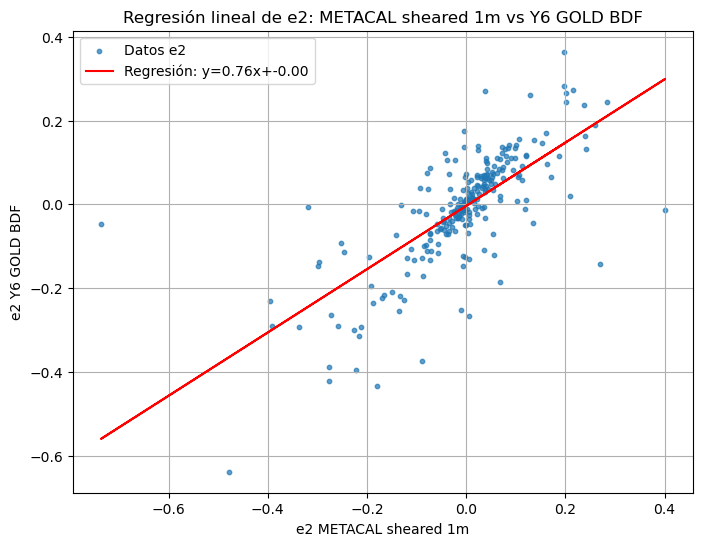

In [11]:
#Extraemos las columnas e1 de ambos surveys de los datos crossmatched
x = crossmatch_y6_gold_metacal_good['sheared_1m_e_2']
y = crossmatch_y6_gold_metacal_good['BDF_G_2']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos e2')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('e2 METACAL sheared 1m')
plt.ylabel('e2 Y6 GOLD BDF')
plt.title('Regresión lineal de e2: METACAL sheared 1m vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 0.9842*x + 0.0027
Coeficiente de correlación (r): 0.8075
Error estándar: 0.0459
p-valor: 4.2650e-58


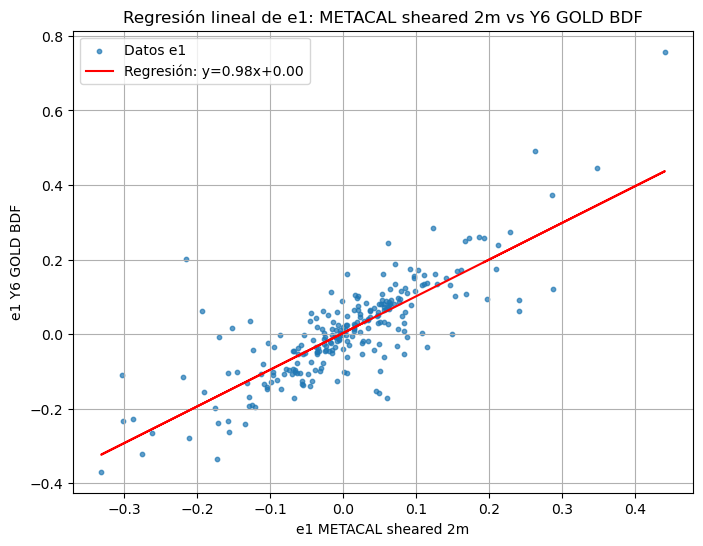

In [12]:
#Extraemos las columnas e1 de ambos surveys de los datos crossmatched
x = crossmatch_y6_gold_metacal_good['sheared_2m_e_1']
y = crossmatch_y6_gold_metacal_good['BDF_G_1']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos e1')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('e1 METACAL sheared 2m')
plt.ylabel('e1 Y6 GOLD BDF')
plt.title('Regresión lineal de e1: METACAL sheared 2m vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 0.7667*x + 0.0014
Coeficiente de correlación (r): 0.7296
Error estándar: 0.0459
p-valor: 2.5342e-42


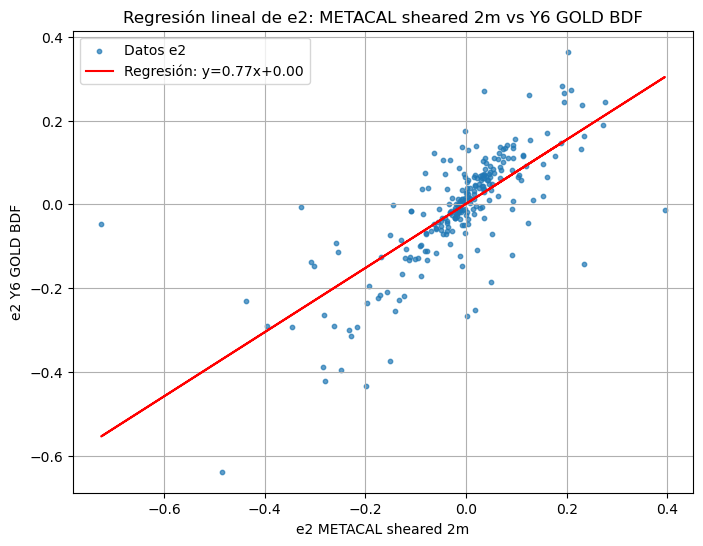

In [13]:
#Extraemos las columnas e1 de ambos surveys de los datos crossmatched
x = crossmatch_y6_gold_metacal_good['sheared_2m_e_2']
y = crossmatch_y6_gold_metacal_good['BDF_G_2']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos e2')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('e2 METACAL sheared 2m')
plt.ylabel('e2 Y6 GOLD BDF')
plt.title('Regresión lineal de e2: METACAL sheared 2m vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 0.9791*x + -0.0006
Coeficiente de correlación (r): 0.8070
Error estándar: 0.0458
p-valor: 5.7416e-58


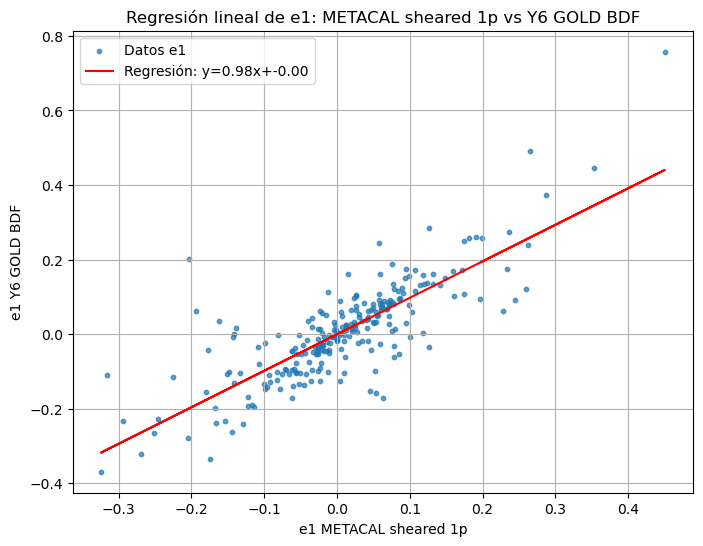

In [14]:
#Extraemos las columnas e1 de ambos surveys de los datos crossmatched
x = crossmatch_y6_gold_metacal_good['sheared_1p_e_1']
y = crossmatch_y6_gold_metacal_good['BDF_G_1']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos e1')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('e1 METACAL sheared 1p')
plt.ylabel('e1 Y6 GOLD BDF')
plt.title('Regresión lineal de e1: METACAL sheared 1p vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 0.7759*x + -0.0029
Coeficiente de correlación (r): 0.7312
Error estándar: 0.0463
p-valor: 1.4163e-42


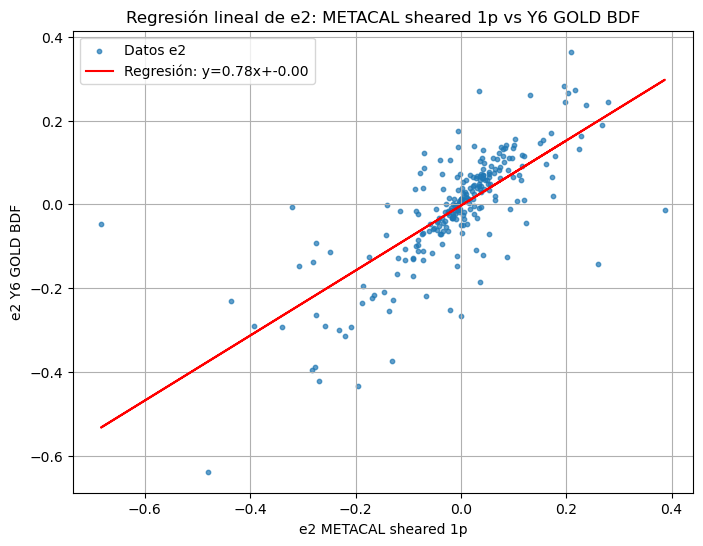

In [15]:
#Extraemos las columnas e1 de ambos surveys de los datos crossmatched
x = crossmatch_y6_gold_metacal_good['sheared_1p_e_2']
y = crossmatch_y6_gold_metacal_good['BDF_G_2']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos e2')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('e2 METACAL sheared 1p')
plt.ylabel('e2 Y6 GOLD BDF')
plt.title('Regresión lineal de e2: METACAL sheared 1p vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 0.9988*x + 0.0021
Coeficiente de correlación (r): 0.8176
Error estándar: 0.0449
p-valor: 1.1351e-60


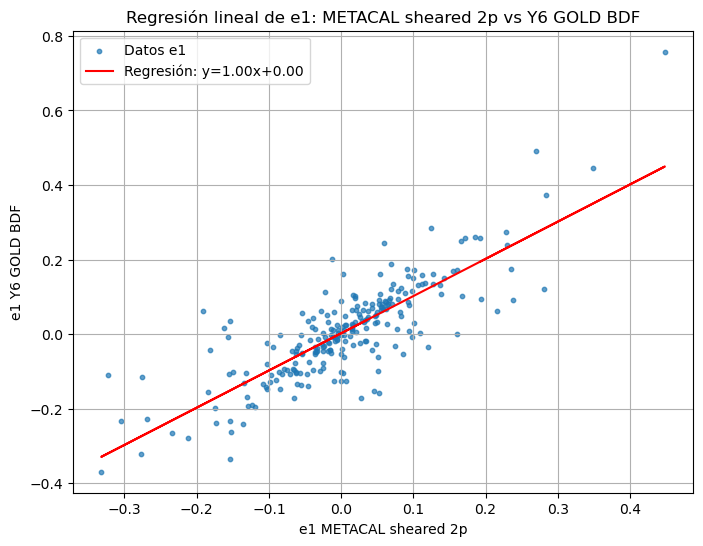

In [16]:
#Extraemos las columnas e1 de ambos surveys de los datos crossmatched
x = crossmatch_y6_gold_metacal_good['sheared_2p_e_1']
y = crossmatch_y6_gold_metacal_good['BDF_G_1']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos e1')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('e1 METACAL sheared 2p')
plt.ylabel('e1 Y6 GOLD BDF')
plt.title('Regresión lineal de e1: METACAL sheared 2p vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 0.8757*x + -0.0093
Coeficiente de correlación (r): 0.7760
Error estándar: 0.0455
p-valor: 6.0417e-51


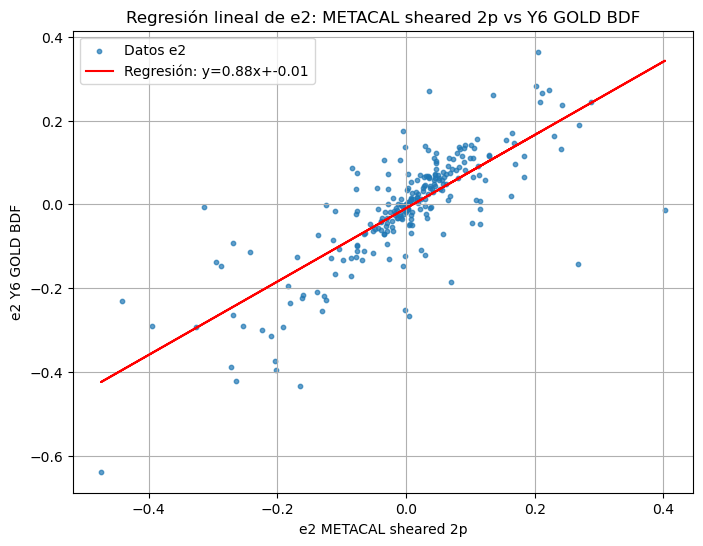

In [17]:
#Extraemos las columnas e1 de ambos surveys de los datos crossmatched
x = crossmatch_y6_gold_metacal_good['sheared_2p_e_2']
y = crossmatch_y6_gold_metacal_good['BDF_G_2']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos e2')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('e2 METACAL sheared 2p')
plt.ylabel('e2 Y6 GOLD BDF')
plt.title('Regresión lineal de e2: METACAL sheared 2p vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

### PA y ejes Y6 GOLD y METACAL

In [18]:
#Definimos una función que nos calcule el PA, los ejes y el módulo de la elipticidad
def calcular_pa_ejes(df, e1_col, e2_col, T_col, prefix):
    
    e1 = df[e1_col].astype(float).to_numpy()
    e2 = df[e2_col].astype(float).to_numpy()
    T  = df[T_col].astype(float).to_numpy()
    
    #modulo de la elipticidad
    eps = np.sqrt(e1**2 + e2**2)
    
    #axis ratio b/a
    q = (1 - eps) / (1 + eps)
    
    #PA
    phi_rad = 0.5*np.arctan2(e2, e1)
    phi = np.degrees(phi_rad) % 180 #para que esté en el rango [0, 180]

    #cálculo de a y b
    arg = T/(1 + q**2) #evitamos que la raíz sea negativa
    a = np.sqrt(np.maximum(arg, 0))
    b = a*q

    #añadimos dependiendo de qué variables se han utilizado
    df[f'{prefix}_a'] = a
    df[f'{prefix}_b'] = b
    df[f'{prefix}_phi'] = phi
    
    return df

In [19]:
crossmatch_y6_m = crossmatch_y6_gold_metacal_good.copy()

#BDF
crossmatch_y6_m = calcular_pa_ejes(crossmatch_y6_m, 'BDF_G_1', 'BDF_G_2', 'BDF_T', prefix='BDF')

#PSF
crossmatch_y6_m = calcular_pa_ejes(crossmatch_y6_m, 'PSF_G_1', 'PSF_G_2', 'PSF_T', prefix='PSF')

#Usheared
crossmatch_y6_m = calcular_pa_ejes(crossmatch_y6_m, 'unsheared_e_1', 'unsheared_e_2', 'unsheared_t', prefix='unsheared')

#Unsheared MCAL PSF
crossmatch_y6_m = calcular_pa_ejes(crossmatch_y6_m, 'unsheared_mcal_psf_e1', 'unsheared_mcal_psf_e2', 'unsheared_mcal_psf_t', prefix='mcal_psf')

#Sheared psf
crossmatch_y6_m = calcular_pa_ejes(crossmatch_y6_m, 'unsheared_psf_e1', 'unsheared_psf_e2', 'unsheared_psf_t', prefix='psf')

#Sheared 1m
crossmatch_y6_m = calcular_pa_ejes(crossmatch_y6_m, 'sheared_1m_e_1', 'sheared_1m_e_2', 'sheared_1m_t', prefix='shear_1m')

#Sheared 2m
crossmatch_y6_m = calcular_pa_ejes(crossmatch_y6_m, 'sheared_2m_e_1', 'sheared_2m_e_2', 'sheared_2m_t', prefix='shear_2m')

#Sheared 1p
crossmatch_y6_m = calcular_pa_ejes(crossmatch_y6_m, 'sheared_1p_e_1', 'sheared_1p_e_2', 'sheared_1p_t', prefix='shear_1p')

#Sheared 2p
crossmatch_y6_m = calcular_pa_ejes(crossmatch_y6_m, 'sheared_2p_e_1', 'sheared_2p_e_2', 'sheared_2p_t', prefix='shear_2p')

#### PA Y6 GOLD BDF vs METACAL

Regresión lineal: y = 0.6084*x + 36.8447
Coeficiente de correlación (r): 0.6055
Error estándar: 0.0511
p-valor: 4.2084e-26


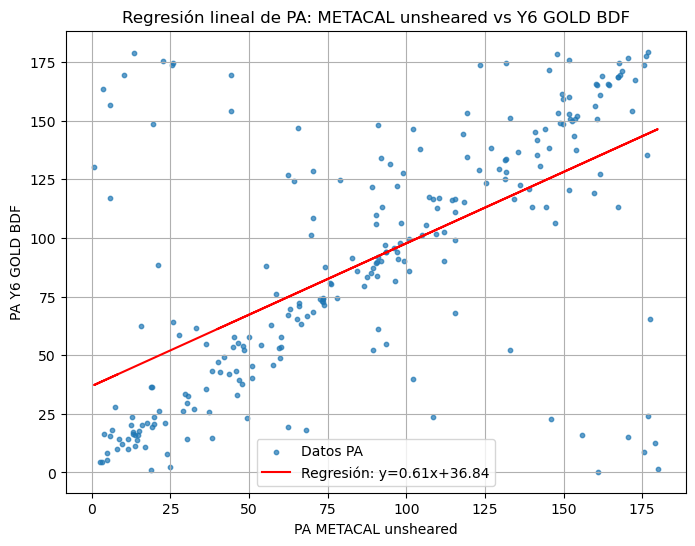

In [20]:
#Extraemos las columnas PA
x = crossmatch_y6_m['unsheared_phi']
y = crossmatch_y6_m['BDF_phi']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos PA')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('PA METACAL unsheared')
plt.ylabel('PA Y6 GOLD BDF')
plt.title('Regresión lineal de PA: METACAL unsheared vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 0.6173*x + 35.6365
Coeficiente de correlación (r): 0.5981
Error estándar: 0.0528
p-valor: 2.3483e-25


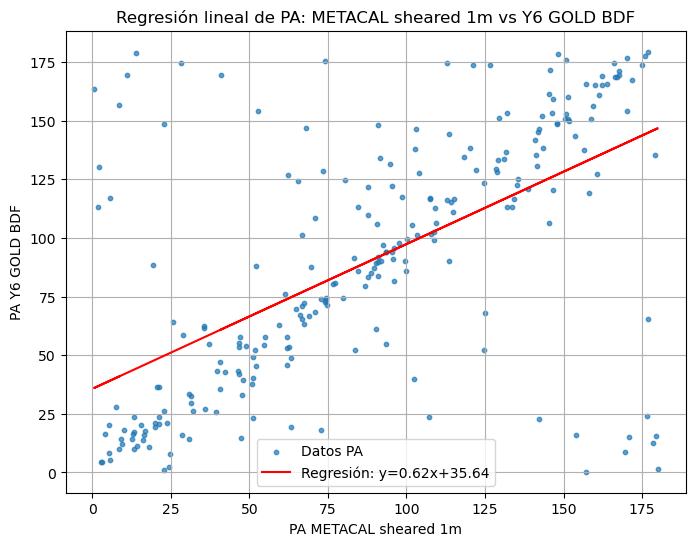

In [21]:
#Extraemos las columnas PA
x = crossmatch_y6_m['shear_1m_phi']
y = crossmatch_y6_m['BDF_phi']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos PA')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('PA METACAL sheared 1m')
plt.ylabel('PA Y6 GOLD BDF')
plt.title('Regresión lineal de PA: METACAL sheared 1m vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 0.5909*x + 35.9244
Coeficiente de correlación (r): 0.5884
Error estándar: 0.0519
p-valor: 2.1100e-24


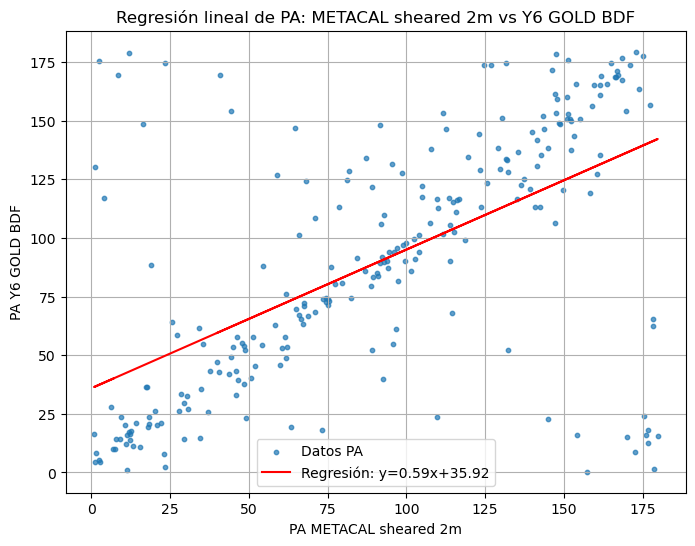

In [22]:
#Extraemos las columnas PA
x = crossmatch_y6_m['shear_2m_phi']
y = crossmatch_y6_m['BDF_phi']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos PA')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('PA METACAL sheared 2m')
plt.ylabel('PA Y6 GOLD BDF')
plt.title('Regresión lineal de PA: METACAL sheared 2m vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 0.5898*x + 38.1378
Coeficiente de correlación (r): 0.5956
Error estándar: 0.0508
p-valor: 4.1820e-25


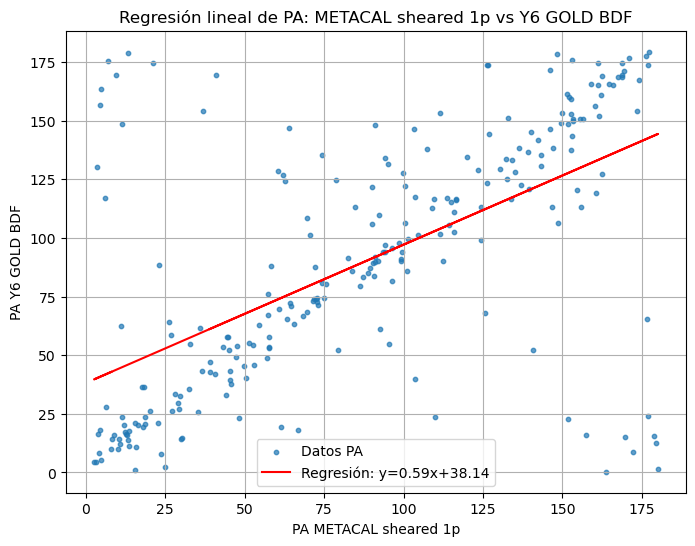

In [23]:
#Extraemos las columnas PA
x = crossmatch_y6_m['shear_1p_phi']
y = crossmatch_y6_m['BDF_phi']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos PA')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('PA METACAL sheared 1p')
plt.ylabel('PA Y6 GOLD BDF')
plt.title('Regresión lineal de PA: METACAL sheared 1p vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 0.6251*x + 37.4223
Coeficiente de correlación (r): 0.6100
Error estándar: 0.0519
p-valor: 1.4434e-26


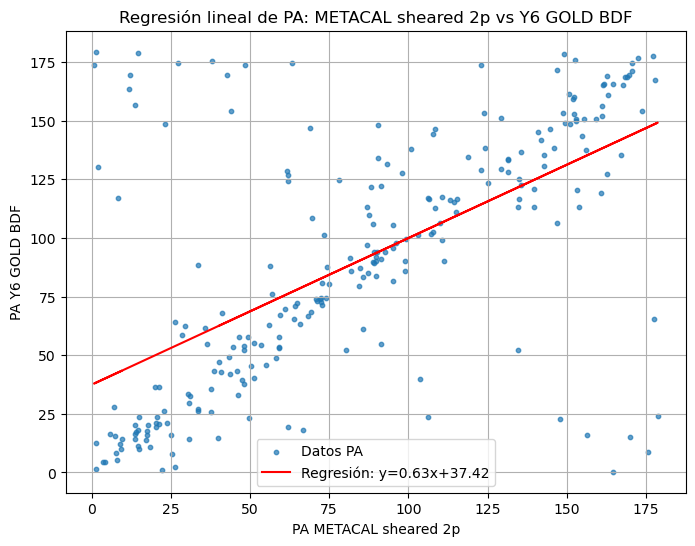

In [24]:
#Extraemos las columnas PA
x = crossmatch_y6_m['shear_2p_phi']
y = crossmatch_y6_m['BDF_phi']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos PA')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('PA METACAL sheared 2p')
plt.ylabel('PA Y6 GOLD BDF')
plt.title('Regresión lineal de PA: METACAL sheared 2p vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

#### a Y6 GOLD BDF vs METACAL

Regresión lineal: y = 6.3599*x + -1.6885
Coeficiente de correlación (r): 0.7927
Error estándar: 0.3125
p-valor: 1.4010e-54


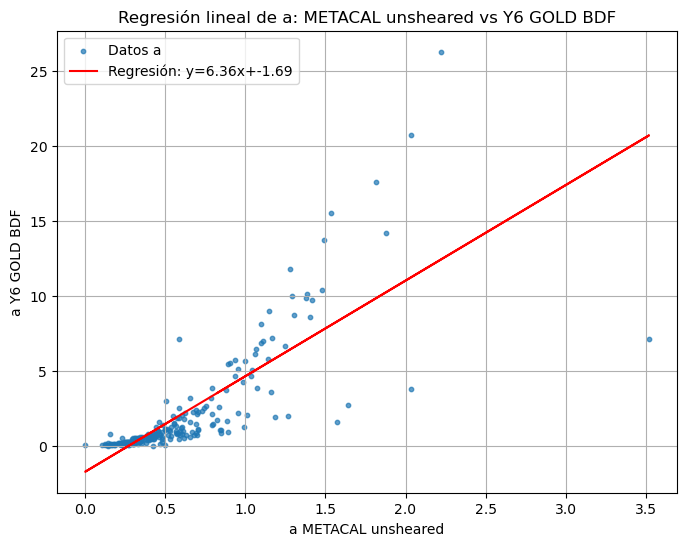

In [25]:
#Extraemos las columnas a
x = crossmatch_y6_m['unsheared_a']
y = crossmatch_y6_m['BDF_a']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos a')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('a METACAL unsheared')
plt.ylabel('a Y6 GOLD BDF')
plt.title('Regresión lineal de a: METACAL unsheared vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 6.2849*x + -1.6690
Coeficiente de correlación (r): 0.7857
Error estándar: 0.3161
p-valor: 5.1032e-53


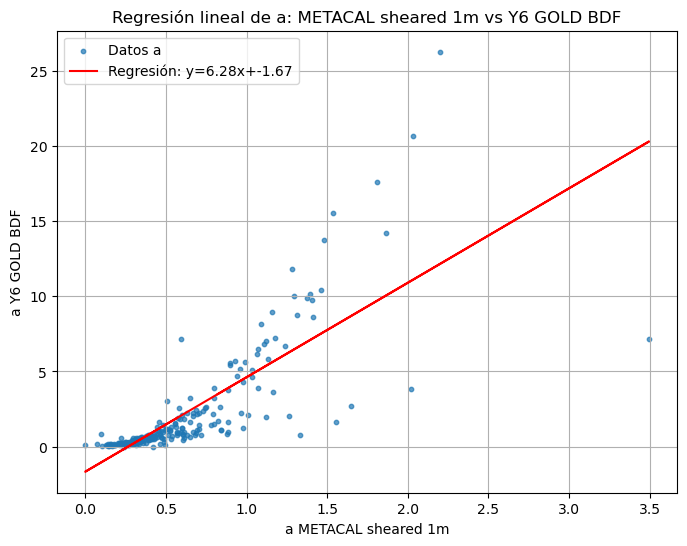

In [26]:
#Extraemos las columnas a
x = crossmatch_y6_m['shear_1m_a']
y = crossmatch_y6_m['BDF_a']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos a')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('a METACAL sheared 1m')
plt.ylabel('a Y6 GOLD BDF')
plt.title('Regresión lineal de a: METACAL sheared 1m vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 6.2931*x + -1.6794
Coeficiente de correlación (r): 0.7853
Error estándar: 0.3170
p-valor: 6.3402e-53


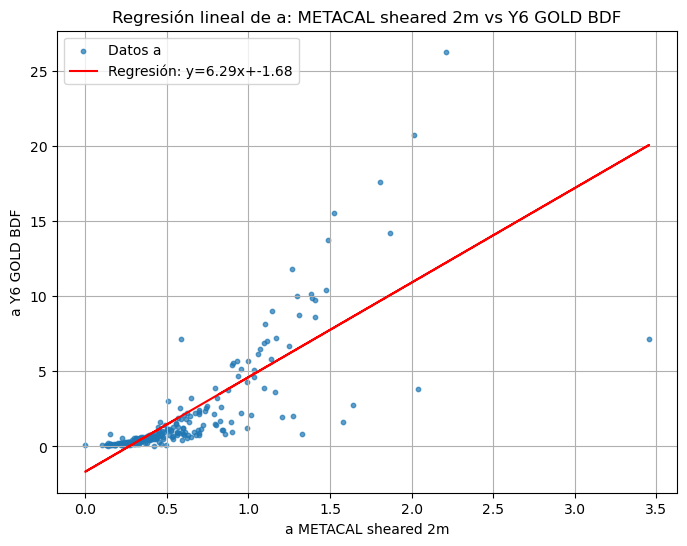

In [27]:
#Extraemos las columnas a
x = crossmatch_y6_m['shear_2m_a']
y = crossmatch_y6_m['BDF_a']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos a')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('a METACAL sheared 2m')
plt.ylabel('a Y6 GOLD BDF')
plt.title('Regresión lineal de a: METACAL sheared 2m vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 6.2540*x + -1.6518
Coeficiente de correlación (r): 0.7855
Error estándar: 0.3148
p-valor: 5.5478e-53


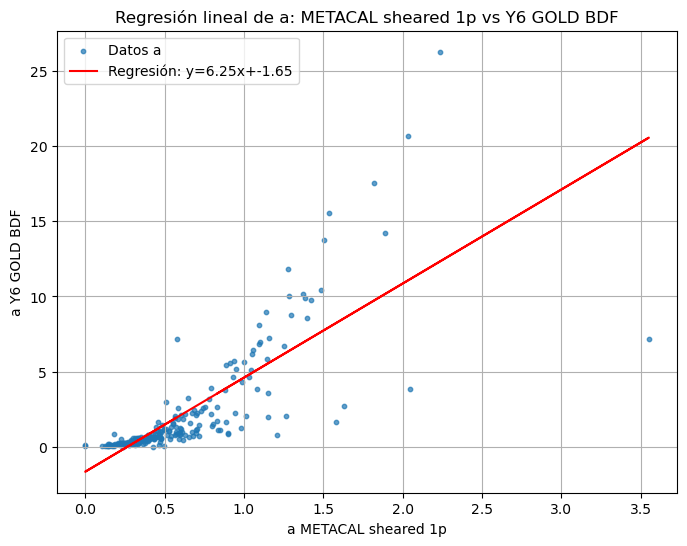

In [28]:
#Extraemos las columnas a
x = crossmatch_y6_m['shear_1p_a']
y = crossmatch_y6_m['BDF_a']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos a')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('a METACAL sheared 1p')
plt.ylabel('a Y6 GOLD BDF')
plt.title('Regresión lineal de a: METACAL sheared 1p vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 6.3192*x + -1.6733
Coeficiente de correlación (r): 0.7916
Error estándar: 0.3116
p-valor: 2.4872e-54


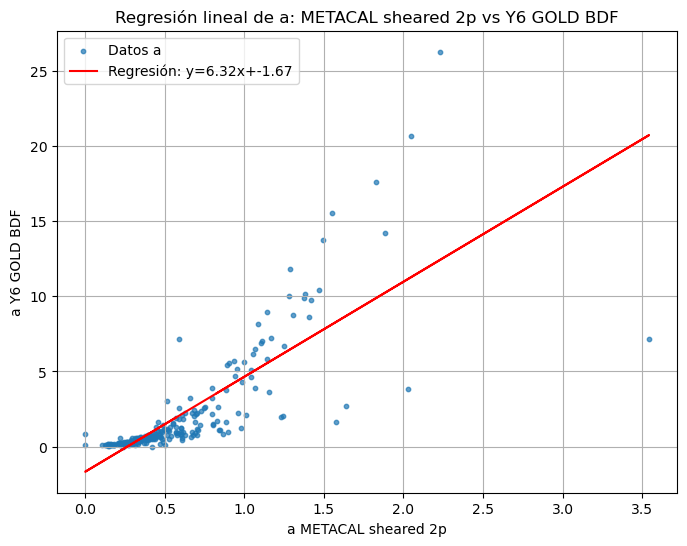

In [29]:
#Extraemos las columnas a
x = crossmatch_y6_m['shear_2p_a']
y = crossmatch_y6_m['BDF_a']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos a')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('a METACAL sheared 2p')
plt.ylabel('a Y6 GOLD BDF')
plt.title('Regresión lineal de a: METACAL sheared 2p vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

#### b Y6 GOLD BDF vs METACAL

Regresión lineal: y = 6.4536*x + -1.3771
Coeficiente de correlación (r): 0.8159
Error estándar: 0.2921
p-valor: 3.0907e-60


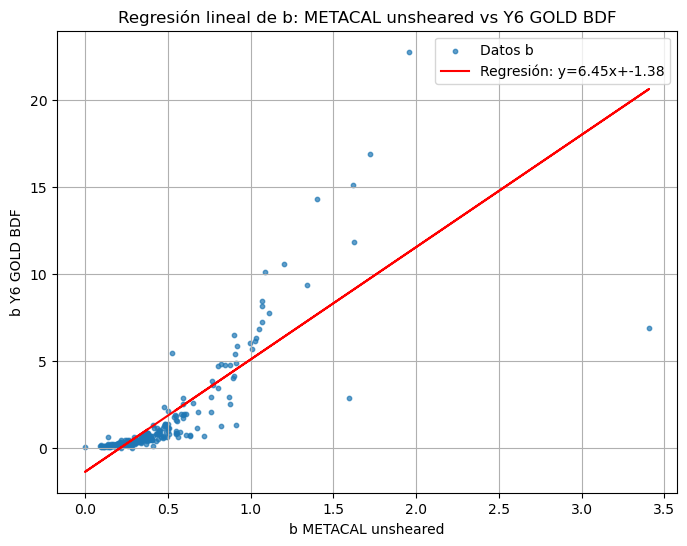

In [30]:
#Extraemos las columnas b
x = crossmatch_y6_m['unsheared_b']
y = crossmatch_y6_m['BDF_b']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos b')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('b METACAL unsheared')
plt.ylabel('b Y6 GOLD BDF')
plt.title('Regresión lineal de b: METACAL unsheared vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 6.4132*x + -1.3542
Coeficiente de correlación (r): 0.8148
Error estándar: 0.2915
p-valor: 6.1364e-60


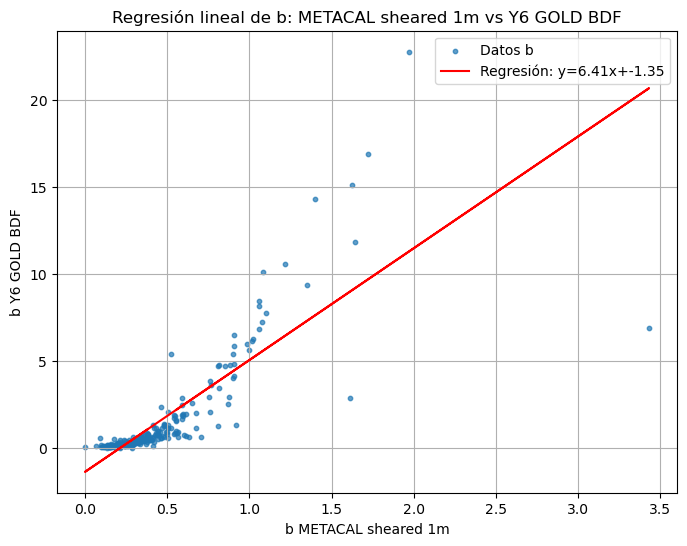

In [31]:
#Extraemos las columnas b
x = crossmatch_y6_m['shear_1m_b']
y = crossmatch_y6_m['BDF_b']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos b')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('b METACAL sheared 1m')
plt.ylabel('b Y6 GOLD BDF')
plt.title('Regresión lineal de b: METACAL sheared 1m vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 6.4929*x + -1.3962
Coeficiente de correlación (r): 0.8194
Error estándar: 0.2902
p-valor: 3.9271e-61


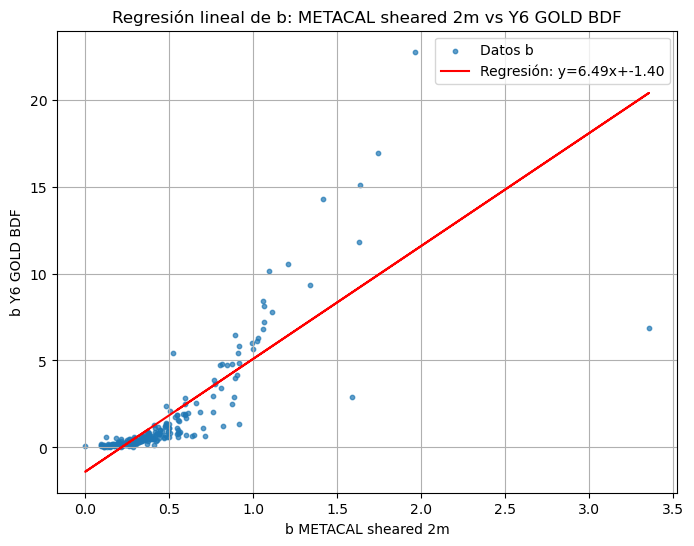

In [32]:
#Extraemos las columnas a
x = crossmatch_y6_m['shear_2m_b']
y = crossmatch_y6_m['BDF_b']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos b')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('b METACAL sheared 2m')
plt.ylabel('b Y6 GOLD BDF')
plt.title('Regresión lineal de b: METACAL sheared 2m vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 6.4789*x + -1.3842
Coeficiente de correlación (r): 0.8162
Error estándar: 0.2930
p-valor: 2.5847e-60


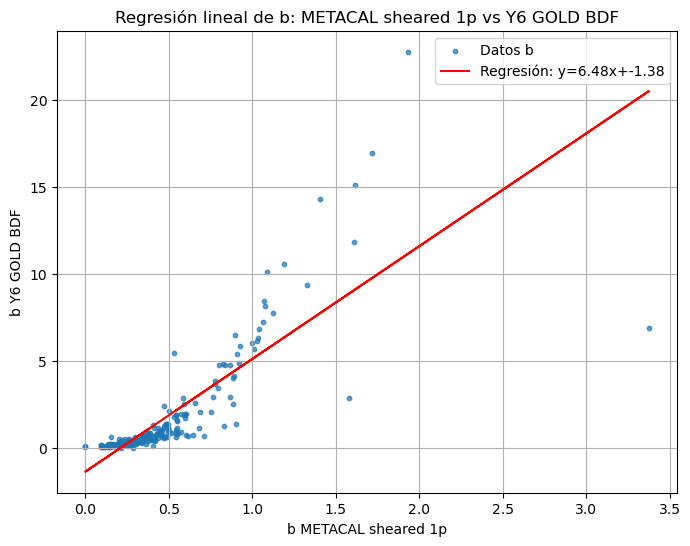

In [33]:
#Extraemos las columnas a
x = crossmatch_y6_m['shear_1p_b']
y = crossmatch_y6_m['BDF_b']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos b')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('b METACAL sheared 1p')
plt.ylabel('b Y6 GOLD BDF')
plt.title('Regresión lineal de b: METACAL sheared 1p vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 6.4566*x + -1.3803
Coeficiente de correlación (r): 0.8140
Error estándar: 0.2944
p-valor: 9.8292e-60


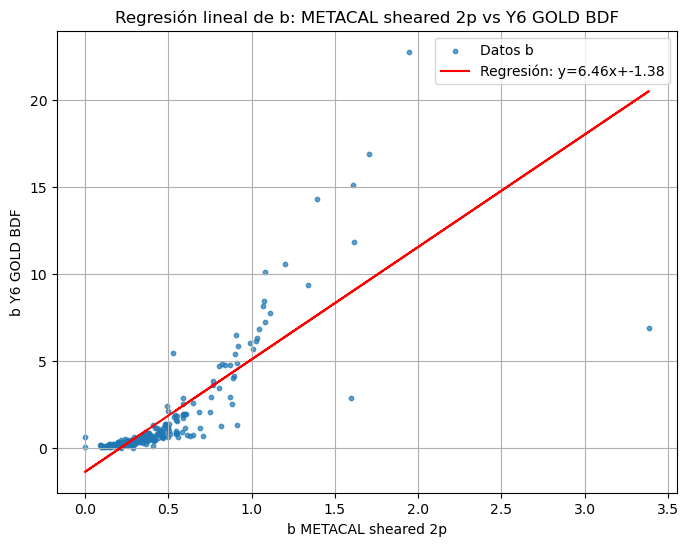

In [34]:
#Extraemos las columnas a
x = crossmatch_y6_m['shear_2p_b']
y = crossmatch_y6_m['BDF_b']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos b')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('b METACAL sheared 2p')
plt.ylabel('b Y6 GOLD BDF')
plt.title('Regresión lineal de b: METACAL sheared 2p vs Y6 GOLD BDF')
plt.legend()
plt.grid(True)
plt.show()

### Scatters PA jet (DES) - PA eje menor

#### PA jet (DES) vs PA eje menor (DES)

In [35]:
#Ruta completa a los archivos
des_all_file = '/mnt/c/Users/Leire/Downloads/des.csv'

#Cargamos el catálogo
des_all = pd.read_csv(des_all_file)

In [36]:
#Filtramos por los que sean galaxias
des_good = des_all[(des_all['DES_full_catalogue_Astrogeo_EXTENDED_CLASS_COADD_matches'].isin([2, 3]))]

Regresión lineal: y = 0.0267*x + 91.2718
Coeficiente de correlación (r): 0.0545
Error estándar: 0.0303
p-valor: 3.7874e-01


/tmp/ipykernel_26452/3698794192.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  des_good.loc[:, 'pos_angle_menor'] = des_good['DES_full_catalogue_Astrogeo_THETA_J2000_matches'] + 90


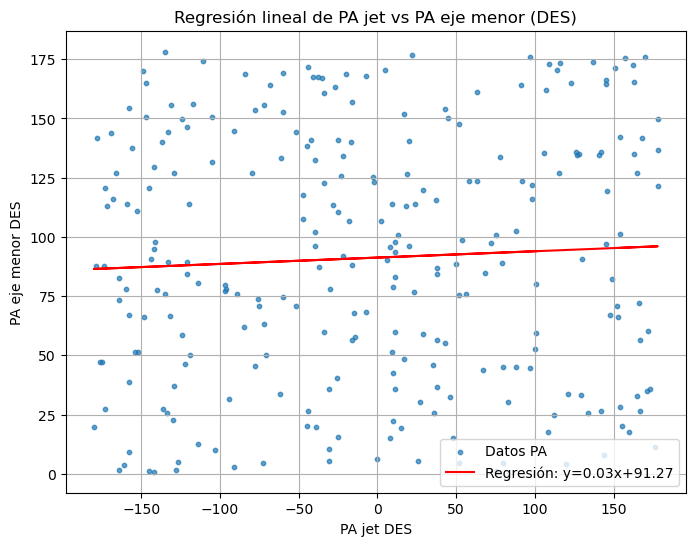

In [37]:
#Extraemos las columnas de PA
des_good.loc[:, 'pos_angle_menor'] = des_good['DES_full_catalogue_Astrogeo_THETA_J2000_matches'] + 90

x = des_good['pa']
y = des_good['pos_angle_menor']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos PA')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('PA jet DES')
plt.ylabel('PA eje menor DES')
plt.title('Regresión lineal de PA jet vs PA eje menor (DES)')
plt.legend()
plt.grid(True)
plt.show()

In [38]:
#Vamos a hacer la resta entre los PA
des_good.loc[:, 'delta_pa'] = np.abs(des_good['pa'] - des_good['pos_angle_menor']) % 180

/tmp/ipykernel_26452/1695896771.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  des_good.loc[:, 'delta_pa'] = np.abs(des_good['pa'] - des_good['pos_angle_menor']) % 180


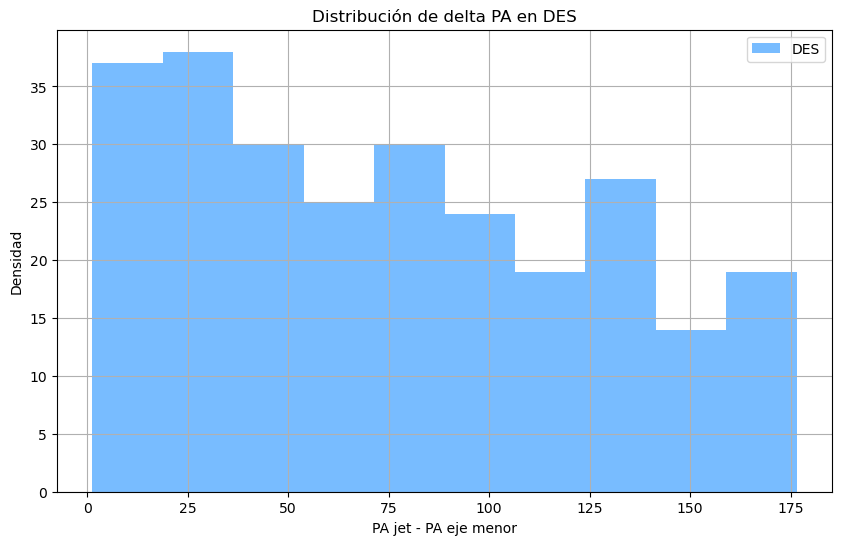

In [39]:
#Histograma de los PA
plt.figure(figsize=(10, 6))
plt.hist(des_good['delta_pa'], bins=10, color='dodgerblue', alpha=0.6, label='DES')
plt.xlabel('PA jet - PA eje menor')
plt.ylabel('Densidad')
plt.title('Distribución de delta PA en DES')
plt.legend()
plt.grid(True)
plt.show()

#### PA jet (DES) vs PA eje menor (BDF Y6 GOLD)

In [40]:
#Ruta completa a los archivos
crossmatch_file = '/mnt/c/Users/Leire/Downloads/crossmatches/Y6_GOLD_2_2_FULL_crossmatch.csv'

#Cargamos el catálogo
y6_gold_crossmatch = pd.read_csv(crossmatch_file)

In [41]:
#Con esto quitamos los objetos que tengan valores de -9999.0 en cualquiera de estas columnas
columnas_malas_y6 = ['BDF_G_1', 'BDF_G_2', 'PSF_G_1', 'PSF_G_2']

mask_y6 = ~(y6_gold_crossmatch[columnas_malas_y6] < -9999.0).any(axis=1)

y6_gold_crossmatch_clean = y6_gold_crossmatch[mask_y6].copy()

print('Objetos totales antes:', len(y6_gold_crossmatch))
print('Objetos eliminados:', (~mask_y6).sum())
print('Objetos restantes:', len(y6_gold_crossmatch_clean))

Objetos totales antes: 744
Objetos eliminados: 2
Objetos restantes: 742


In [42]:
#Filtramos por los que sean galaxias
y6_gold_crossmatch_good = y6_gold_crossmatch_clean[(y6_gold_crossmatch_clean['DES_full_catalogue_Astrogeo_EXTENDED_CLASS_COADD_matches'].isin([2, 3]))]

In [43]:
print('Objetos totales antes:', len(y6_gold_crossmatch))
print('Objetos eliminados:', (~mask_y6).sum())
print('Objetos restantes:', len(y6_gold_crossmatch_clean))
print('Galaxias:', len(y6_gold_crossmatch_good))

Objetos totales antes: 744
Objetos eliminados: 2
Objetos restantes: 742
Galaxias: 261


In [44]:
#Calculamos los PA y ejes a partir de las elipticidades
crossmatch_y6 = y6_gold_crossmatch_good.copy()

#BDF
crossmatch_y6 = calcular_pa_ejes(crossmatch_y6, 'BDF_G_1', 'BDF_G_2', 'BDF_T', prefix='BDF')

Regresión lineal: y = -0.0433*x + 179.9249
Coeficiente de correlación (r): -0.0861
Error estándar: 0.0311
p-valor: 1.6553e-01


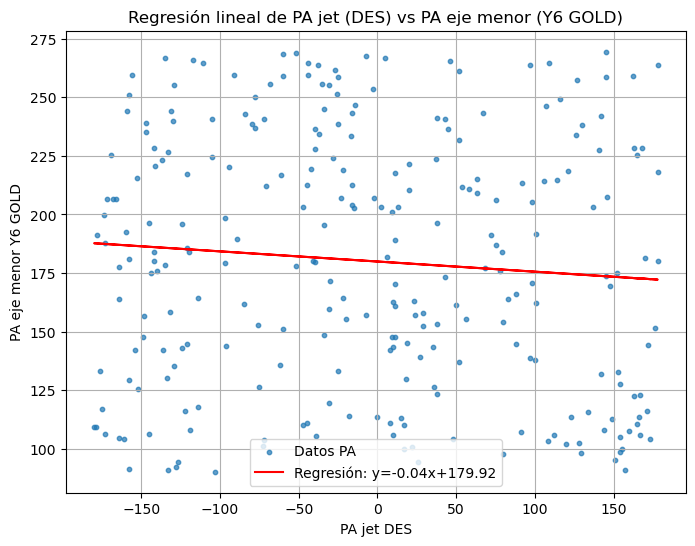

In [45]:
#Extraemos las columnas de PA
crossmatch_y6['BDF_phi_menor'] = crossmatch_y6['BDF_phi'] + 90

x = crossmatch_y6['pa']
y = crossmatch_y6['BDF_phi_menor']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos PA')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('PA jet DES')
plt.ylabel('PA eje menor Y6 GOLD')
plt.title('Regresión lineal de PA jet (DES) vs PA eje menor (Y6 GOLD)')
plt.legend()
plt.grid(True)
plt.show()

In [46]:
#Vamos a hacer la resta entre los PA
crossmatch_y6.loc[:, 'delta_pa'] = np.abs(crossmatch_y6['pa'] - crossmatch_y6['BDF_phi_menor']) % 180

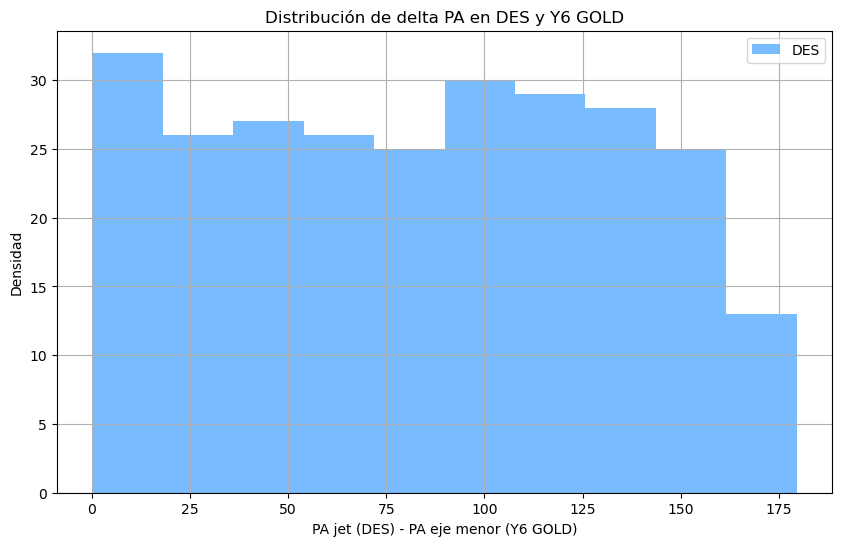

In [47]:
#Histograma de los PA
plt.figure(figsize=(10, 6))
plt.hist(crossmatch_y6['delta_pa'], bins=10, color='dodgerblue', alpha=0.6, label='DES')
plt.xlabel('PA jet (DES) - PA eje menor (Y6 GOLD)')
plt.ylabel('Densidad')
plt.title('Distribución de delta PA en DES y Y6 GOLD')
plt.legend()
plt.grid(True)
plt.show()

#### PA jet (DES) vs PA eje menor (METACAL)

In [48]:
#Ruta completa a los archivos
des_metacal_file = '/mnt/c/Users/Leire/Downloads/xmatch_des_metacal.csv'

#Cargamos el catálogo
crossmatch_des_metacal = pd.read_csv(des_metacal_file)

In [49]:
#Con esto quitamos los objetos que tengan valores de -9999.0 en cualquiera de estas columnas
columnas_malas = ['unsheared_mcal_psf_e1', 'unsheared_psf_e1', 'sheared_1m_e_1', 'sheared_2m_e_1', 'sheared_1p_e_1', 'sheared_2p_e_1',
    'unsheared_mcal_psf_e2', 'unsheared_psf_e2','sheared_1m_e_2', 'sheared_2m_e_2', 'sheared_1p_e_2', 'sheared_2p_e_2']

mask = ~(crossmatch_des_metacal[columnas_malas] == -9999.0).any(axis=1)

crossmatch_des_metacal_clean = crossmatch_des_metacal[mask].copy()

print('Objetos totales antes:', len(crossmatch_des_metacal))
print('Objetos eliminados:', (~mask).sum())
print('Objetos restantes:', len(crossmatch_des_metacal_clean))

Objetos totales antes: 724
Objetos eliminados: 12
Objetos restantes: 712


In [50]:
#Filtramos por los que sean galaxias
crossmatch_des_metacal_good = crossmatch_des_metacal_clean[(crossmatch_des_metacal_clean['DES_full_catalogue_Astrogeo_EXTENDED_CLASS_COADD_matches'].isin([2, 3]))]

In [51]:
print('Objetos totales antes:', len(crossmatch_des_metacal))
print('Objetos eliminados:', (~mask).sum())
print('Objetos restantes:', len(crossmatch_des_metacal_clean))
print('Galaxias:', len(crossmatch_des_metacal_good))

Objetos totales antes: 724
Objetos eliminados: 12
Objetos restantes: 712
Galaxias: 248


In [52]:
#Calculamos los PA y ejes a partir de las elipticidades
crossmatch_dm = crossmatch_des_metacal_good.copy()

#Usheared
crossmatch_dm = calcular_pa_ejes(crossmatch_dm, 'unsheared_e_1', 'unsheared_e_2', 'unsheared_t', prefix='unsheared')

#Unsheared MCAL PSF
crossmatch_dm = calcular_pa_ejes(crossmatch_dm, 'unsheared_mcal_psf_e1', 'unsheared_mcal_psf_e2', 'unsheared_mcal_psf_t', prefix='mcal_psf')

#Sheared psf
crossmatch_dm = calcular_pa_ejes(crossmatch_dm, 'unsheared_psf_e1', 'unsheared_psf_e2', 'unsheared_psf_t', prefix='psf')

#Sheared 1m
crossmatch_dm = calcular_pa_ejes(crossmatch_dm, 'sheared_1m_e_1', 'sheared_1m_e_2', 'sheared_1m_t', prefix='shear_1m')

#Sheared 2m
crossmatch_dm = calcular_pa_ejes(crossmatch_dm, 'sheared_2m_e_1', 'sheared_2m_e_2', 'sheared_2m_t', prefix='shear_2m')

#Sheared 1p
crossmatch_dm = calcular_pa_ejes(crossmatch_dm, 'sheared_1p_e_1', 'sheared_1p_e_2', 'sheared_1p_t', prefix='shear_1p')

#Sheared 2p
crossmatch_dm = calcular_pa_ejes(crossmatch_dm, 'sheared_2p_e_1', 'sheared_2p_e_2', 'sheared_2p_t', prefix='shear_2p')

Regresión lineal: y = 0.0201*x + 176.8962
Coeficiente de correlación (r): 0.0401
Error estándar: 0.0319
p-valor: 5.2930e-01


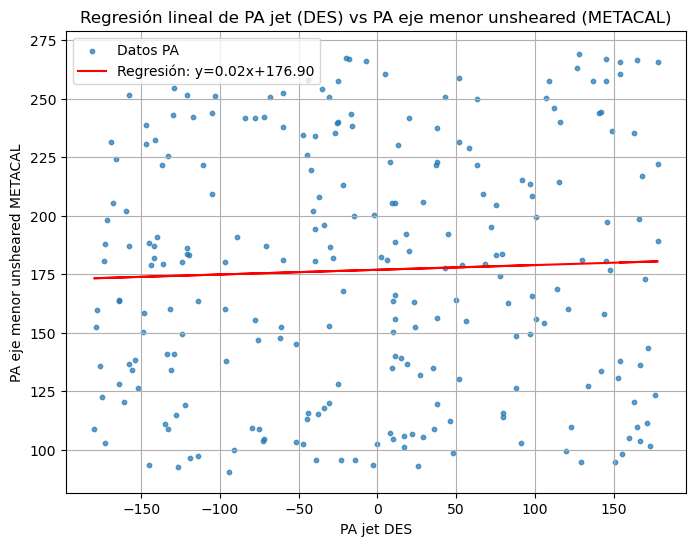

In [53]:
#Extraemos las columnas de PA
crossmatch_dm['unsheared_phi_menor'] = crossmatch_dm['unsheared_phi'] + 90

x = crossmatch_dm['pa']
y = crossmatch_dm['unsheared_phi_menor']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos PA')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('PA jet DES')
plt.ylabel('PA eje menor unsheared METACAL')
plt.title('Regresión lineal de PA jet (DES) vs PA eje menor unsheared (METACAL)')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 0.0107*x + 177.5256
Coeficiente de correlación (r): 0.0219
Error estándar: 0.0311
p-valor: 7.3118e-01


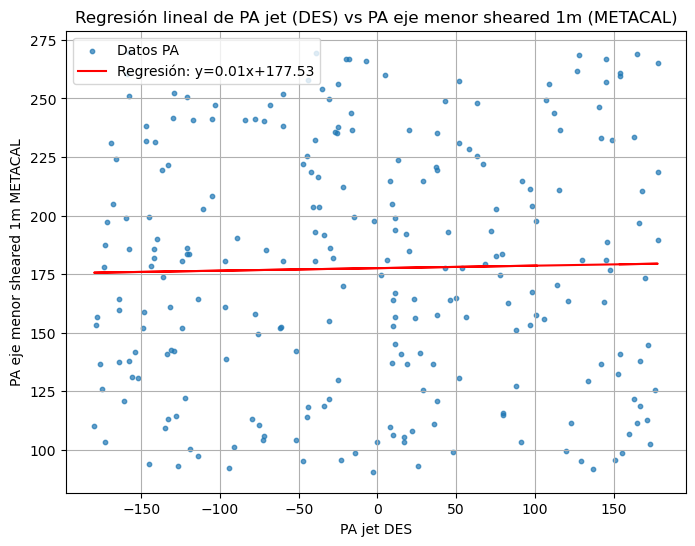

In [54]:
#Extraemos las columnas de PA
crossmatch_dm['shear_1m_phi_menor'] = crossmatch_dm['shear_1m_phi'] + 90

x = crossmatch_dm['pa']
y = crossmatch_dm['shear_1m_phi_menor']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos PA')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('PA jet DES')
plt.ylabel('PA eje menor sheared 1m METACAL')
plt.title('Regresión lineal de PA jet (DES) vs PA eje menor sheared 1m (METACAL)')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 0.0177*x + 180.9905
Coeficiente de correlación (r): 0.0353
Error estándar: 0.0320
p-valor: 5.8018e-01


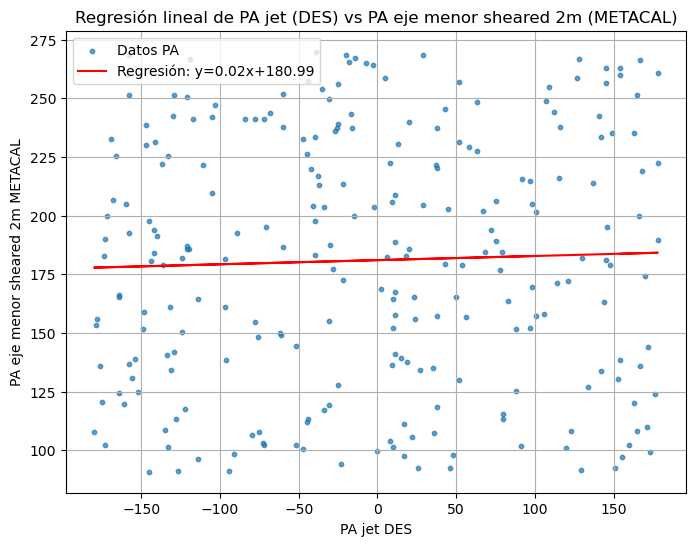

In [55]:
#Extraemos las columnas de PA
crossmatch_dm['shear_2m_phi_menor'] = crossmatch_dm['shear_2m_phi'] + 90

x = crossmatch_dm['pa']
y = crossmatch_dm['shear_2m_phi_menor']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos PA')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('PA jet DES')
plt.ylabel('PA eje menor sheared 2m METACAL')
plt.title('Regresión lineal de PA jet (DES) vs PA eje menor sheared 2m (METACAL)')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = 0.0077*x + 177.3629
Coeficiente de correlación (r): 0.0152
Error estándar: 0.0324
p-valor: 8.1137e-01


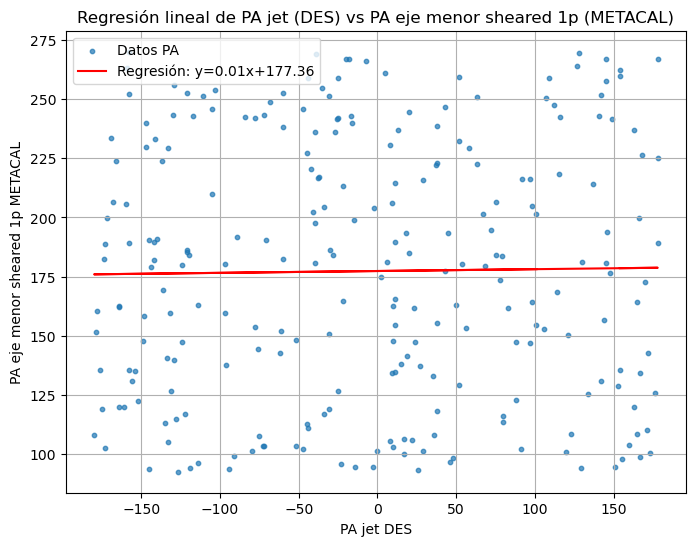

In [56]:
#Extraemos las columnas de PA
crossmatch_dm['shear_1p_phi_menor'] = crossmatch_dm['shear_1p_phi'] + 90

x = crossmatch_dm['pa']
y = crossmatch_dm['shear_1p_phi_menor']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos PA')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('PA jet DES')
plt.ylabel('PA eje menor sheared 1p METACAL')
plt.title('Regresión lineal de PA jet (DES) vs PA eje menor sheared 1p (METACAL)')
plt.legend()
plt.grid(True)
plt.show()

Regresión lineal: y = -0.0002*x + 173.5202
Coeficiente de correlación (r): -0.0004
Error estándar: 0.0313
p-valor: 9.9540e-01


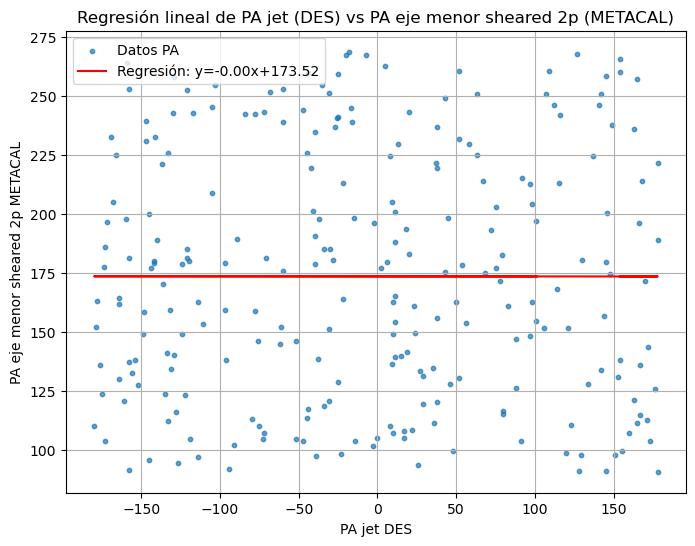

In [57]:
#Extraemos las columnas de PA
crossmatch_dm['shear_2p_phi_menor'] = crossmatch_dm['shear_2p_phi'] + 90

x = crossmatch_dm['pa']
y = crossmatch_dm['shear_2p_phi_menor']

#Evitamos NaNs
mask = (~np.isnan(x)) & (~np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

#Hacemos la regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)

print(f'Regresión lineal: y = {slope:.4f}*x + {intercept:.4f}')
print(f'Coeficiente de correlación (r): {r_value:.4f}')
print(f'Error estándar: {std_err:.4f}')
print(f'p-valor: {p_value:.4e}')

#Dibujamos scatter y línea ajustada
plt.figure(figsize=(8, 6))
plt.scatter(x_clean, y_clean, s=10, alpha=0.7, label='Datos PA')

#Línea de regresión
plt.plot(x_clean, slope*x_clean + intercept, color='red', label=f'Regresión: y={slope:.2f}x+{intercept:.2f}')

plt.xlabel('PA jet DES')
plt.ylabel('PA eje menor sheared 2p METACAL')
plt.title('Regresión lineal de PA jet (DES) vs PA eje menor sheared 2p (METACAL)')
plt.legend()
plt.grid(True)
plt.show()

In [58]:
#Vamos a hacer la resta entre los PA
crossmatch_dm.loc[:, 'delta_pa_unsheared'] = np.abs(crossmatch_dm['pa'] - crossmatch_dm['unsheared_phi_menor']) % 180
crossmatch_dm.loc[:, 'delta_pa_shear_1m'] = np.abs(crossmatch_dm['pa'] - crossmatch_dm['shear_1m_phi_menor']) % 180
crossmatch_dm.loc[:, 'delta_pa_shear_2m'] = np.abs(crossmatch_dm['pa'] - crossmatch_dm['shear_2m_phi_menor']) % 180
crossmatch_dm.loc[:, 'delta_pa_shear_1p'] = np.abs(crossmatch_dm['pa'] - crossmatch_dm['shear_1p_phi_menor']) % 180
crossmatch_dm.loc[:, 'delta_pa_shear_2p'] = np.abs(crossmatch_dm['pa'] - crossmatch_dm['shear_2p_phi_menor']) % 180

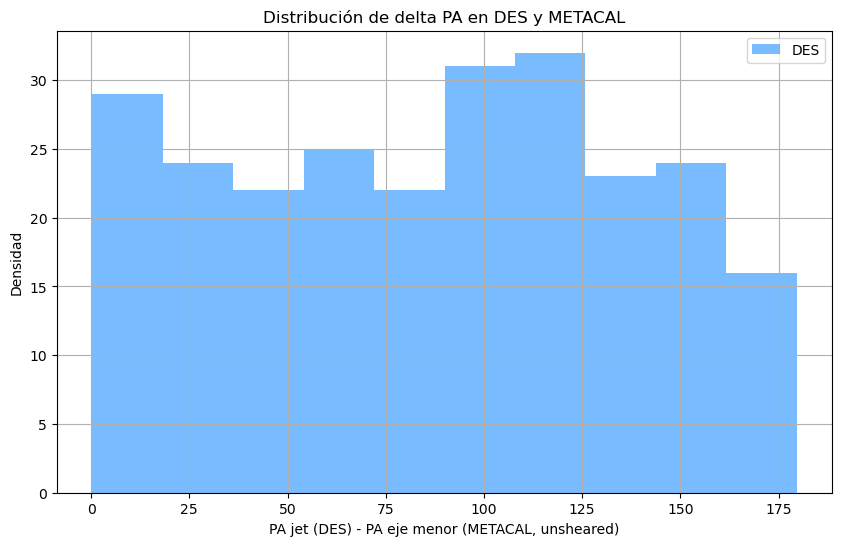

In [59]:
#Histograma de los PA
plt.figure(figsize=(10, 6))
plt.hist(crossmatch_dm['delta_pa_unsheared'], bins=10, color='dodgerblue', alpha=0.6, label='DES')
plt.xlabel('PA jet (DES) - PA eje menor (METACAL, unsheared)')
plt.ylabel('Densidad')
plt.title('Distribución de delta PA en DES y METACAL')
plt.legend()
plt.grid(True)
plt.show()

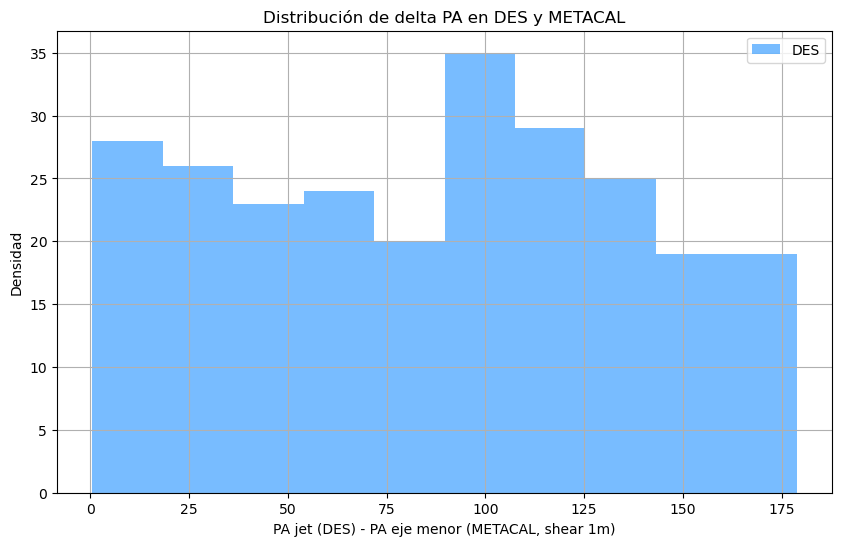

In [60]:
#Histograma de los PA
plt.figure(figsize=(10, 6))
plt.hist(crossmatch_dm['delta_pa_shear_1m'], bins=10, color='dodgerblue', alpha=0.6, label='DES')
plt.xlabel('PA jet (DES) - PA eje menor (METACAL, shear 1m)')
plt.ylabel('Densidad')
plt.title('Distribución de delta PA en DES y METACAL')
plt.legend()
plt.grid(True)
plt.show()

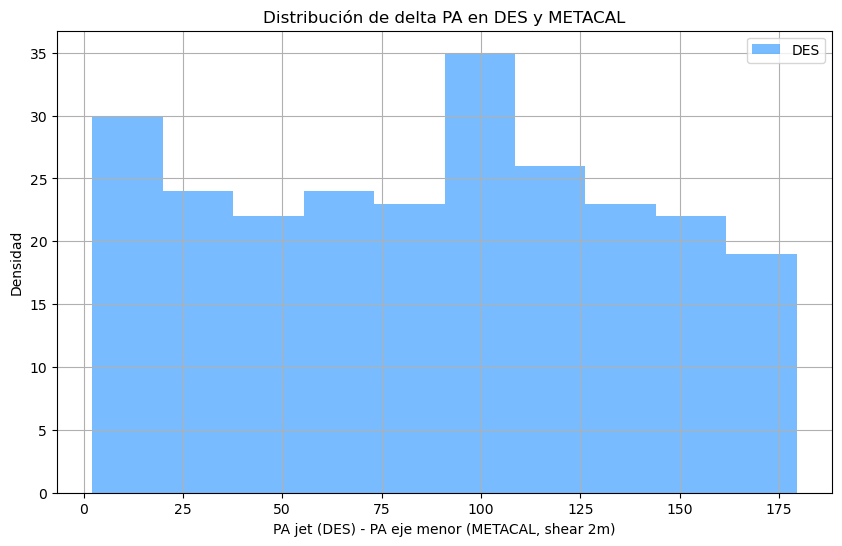

In [61]:
#Histograma de los PA
plt.figure(figsize=(10, 6))
plt.hist(crossmatch_dm['delta_pa_shear_2m'], bins=10, color='dodgerblue', alpha=0.6, label='DES')
plt.xlabel('PA jet (DES) - PA eje menor (METACAL, shear 2m)')
plt.ylabel('Densidad')
plt.title('Distribución de delta PA en DES y METACAL')
plt.legend()
plt.grid(True)
plt.show()

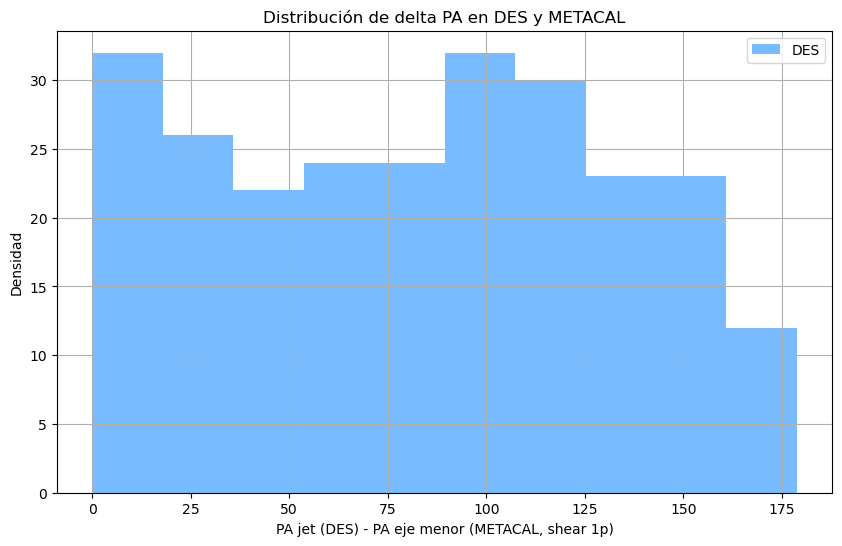

In [62]:
#Histograma de los PA
plt.figure(figsize=(10, 6))
plt.hist(crossmatch_dm['delta_pa_shear_1p'], bins=10, color='dodgerblue', alpha=0.6, label='DES')
plt.xlabel('PA jet (DES) - PA eje menor (METACAL, shear 1p)')
plt.ylabel('Densidad')
plt.title('Distribución de delta PA en DES y METACAL')
plt.legend()
plt.grid(True)
plt.show()

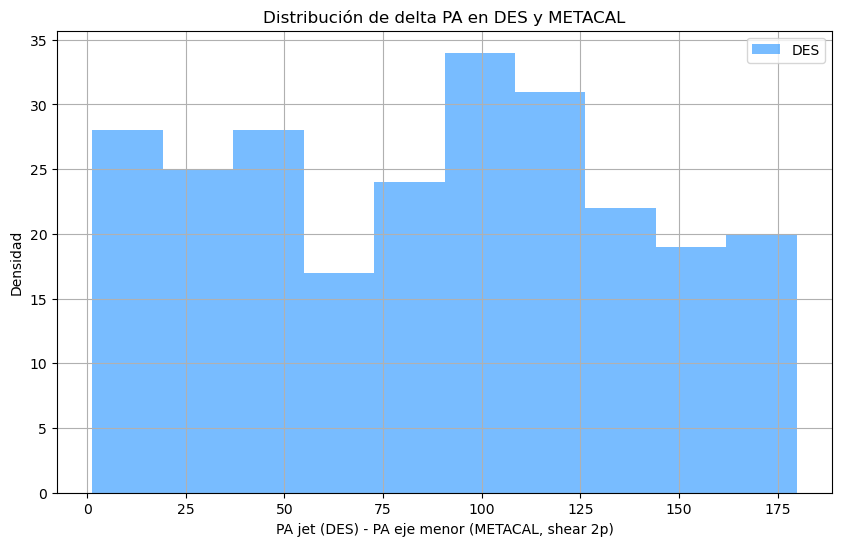

In [63]:
#Histograma de los PA
plt.figure(figsize=(10, 6))
plt.hist(crossmatch_dm['delta_pa_shear_2p'], bins=10, color='dodgerblue', alpha=0.6, label='DES')
plt.xlabel('PA jet (DES) - PA eje menor (METACAL, shear 2p)')
plt.ylabel('Densidad')
plt.title('Distribución de delta PA en DES y METACAL')
plt.legend()
plt.grid(True)
plt.show()